In [1]:
from langgraph.graph import StateGraph, START, END
import json
from estado import AgentState
from estado import Nivel
from buscador_programas import programas_nacionales_openai_node, decide_iterate

In [2]:
builder = StateGraph(AgentState)
# Añadir el nodo
builder.add_node("buscador_openai", programas_nacionales_openai_node)
builder.add_edge(START, "buscador_openai")
builder.add_conditional_edges("buscador_openai", 
                              decide_iterate, 
                              {"iterar": "buscador_openai", "terminar": END})
#builder.add_edge("buscador_openai", END)

graph = builder.compile()

In [3]:
import os
with open("./salida/final_state.json", "r", encoding="utf-8") as f:
    state_json = f.read()
    estado_inicial = AgentState.model_validate_json(state_json)
print("ANTES:", len(estado_inicial.informacion_programas_nacionales or []))
#print(type(estado_inicial))        
final_state = graph.invoke(estado_inicial)
final_state = AgentState.model_validate(final_state)

print("DESPUÉS:", len(estado_inicial.informacion_programas_nacionales or []))

with open("salida/final_state.json", "w", encoding="utf-8") as f:
    f.write(final_state.model_dump_json(indent=4, ensure_ascii=False))

ANTES: 22
Buscando información del programa: Ingenieria Nanotecnologia de la institución: Universidad Pontificia Bolivariana
Buscando información del programa: Ingenieria Materiales de la institución: Universidad Santo Tomas
Buscando información del programa: Ingenieria Materiales de la institución: Universidad Medellin
Buscando información del programa: Ingenieria Materiales de la institución: Fundacion Universitaria Monserrate -Unimonserrate
Buscando información del programa: Especializacion Nanotecnologia Aplicada Industria Petroleo Gas de la institución: Universidad Nacional Colombia
Buscando información del programa: Ingenieria Materiales de la institución: Institucion Universitaria Pascual Bravo
Buscando información del programa: Especializacion Nanotecnologia de la institución: Universidad Nacional Colombia
Buscando información del programa: Especializacion Ingenieria Materiales Procesos de la institución: Universidad Nacional Colombia
Buscando información del programa: Especial

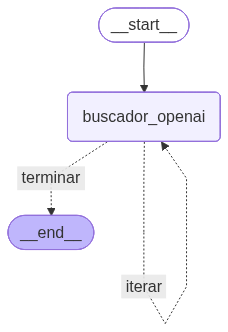

In [6]:
#print(graph.get_graph().draw_ascii())

from IPython.display import Image, display
png_bytes = graph.get_graph().draw_mermaid_png()
display(Image(png_bytes))